<a href="https://colab.research.google.com/github/samikshasali/NLP-Preprocessing-Engine/blob/main/Sentiment_Analysis_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 2: Load Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Step 3: Data Understanding

In [3]:
print("Shape:", df.shape)
print(df['sentiment'].value_counts())
print(df.isnull().sum())

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
review       0
sentiment    0
dtype: int64


# Step 4: NLP Preprocessing

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()  # lowercase
    text = re.sub(r"<.*?>", "", text)  # remove HTML tags
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z]", " ", text)  # remove punctuation

    words = text.split()  # tokenization

    words = [w for w in words if w not in stop_words]  # stopword removal
    words = [lemmatizer.lemmatize(w) for w in words]  # lemmatization

    return " ".join(words)

df['clean_review'] = df['review'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


# Step 5: Convert Labels to Numbers

In [5]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# Step 6: Feature Engineering - TF-IDF

In [6]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

# Step 7: Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Model Training

In [8]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [9]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [10]:
dt = DecisionTreeClassifier(max_depth=10)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

# Step 9: Evaluation Function

In [11]:
def evaluate(model, name):
    y_pred = model.predict(X_test)

    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print()

# Step 10: Evaluate All Models

In [12]:
evaluate(lr, "Logistic Regression")
evaluate(nb, "Naive Bayes")
evaluate(dt, "Decision Tree")

--- Logistic Regression ---
Accuracy: 0.8894
Precision: 0.88
Recall: 0.9037507441952768
F1 Score: 0.8917172508321911

--- Naive Bayes ---
Accuracy: 0.8551
Precision: 0.8519607843137255
Recall: 0.862274260766025
F1 Score: 0.8570864976822172

--- Decision Tree ---
Accuracy: 0.7305
Precision: 0.6915032679738562
Recall: 0.8398491764238937
F1 Score: 0.7584909042028856



# Step 11: Comparison

1. Logistic Regression performed best because it handles high-dimensional sparse data well.
2. Naive Bayes was fast but slightly less accurate.
3. Decision Tree showed lower performance due to overfitting.
4. TF-IDF improved results compared to simple Bag of Words.


# Step 12: Final Prediction Function

In [13]:
def predict_sentiment(text):
    text = preprocess(text)
    vec = tfidf.transform([text])
    pred = lr.predict(vec)

    return "Positive" if pred[0] == 1 else "Negative"

# Test
print(predict_sentiment("This movie was amazing!"))

Positive


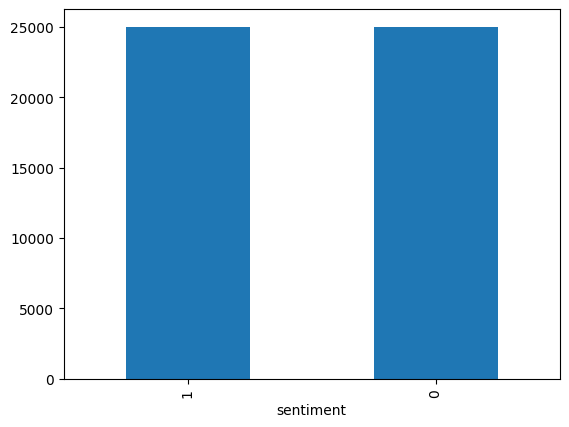

In [14]:
import matplotlib.pyplot as plt
df['sentiment'].value_counts().plot(kind='bar')
plt.show()